# 04_stability

This notebook evaluates the **stability and robustness** of multiplicity hotspots
across multiple experimental runs (e.g. different random seeds or ε values).

**Goal**

> Show that hotspot points and regions are **reproducible**, not threshold or sampling noise.

## 1. Imports

In [5]:
import sys
from pathlib import Path

# Add parent directory to path to import analysis module
# In Jupyter, cwd is usually the project root, but we check both
project_root = Path.cwd()
if not (project_root / 'analysis').exists():
    # If analysis/ not in cwd, try parent directory
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from analysis.spatial import build_knn_graph, lisa_local, extract_hh_components
from analysis.stability import (
    hh_selection_frequency,
    hh_jaccard_matrix,
    summarize_hh_stability,
)

## 2. Locate multiple experiment runs

In [7]:
# Adjust to the directory containing multiple seeds / epsilons
BASE_DIR = Path("../results/compas")

RUN_DIRS = sorted([p for p in BASE_DIR.iterdir() if p.is_dir()])
print("Found runs:")
for p in RUN_DIRS:
    print(" ", p.name)

Found runs:
  family=GBM
  family=LogReg
  family=MLP
  family=RF
  global
  seed=42_eps=0.01


## 3. Load HH masks from each run

In [8]:
hh_masks = []

for run_dir in RUN_DIRS:
    # Handle nested directory structure: some dirs have files directly,
    # others have them in seed=*_eps=* subdirectories
    if (run_dir / "P_test.npy").exists():
        data_dir = run_dir
    else:
        # Look for subdirectories matching seed=*_eps=* pattern
        seed_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and "seed=" in d.name and "eps=" in d.name])
        if seed_dirs:
            data_dir = seed_dirs[0]  # Use first matching subdirectory
            print(f"  Using subdirectory: {data_dir.name} (from {run_dir.name})")
        else:
            raise FileNotFoundError(f"Could not find P_test.npy in {run_dir} or its subdirectories")
    
    P = np.load(data_dir / "P_test.npy")
    metrics = np.load(data_dir / "metrics.npz")
    X_test = pd.read_csv(data_dir / "X_test.csv")

    v = metrics["variance"]

    # numeric-only adjacency
    X_knn = X_test.select_dtypes(include=[np.number])
    W = build_knn_graph(X_knn, k=10)

    lisa = lisa_local(v, W)
    hh_masks.append(lisa["cluster"].values == "HH")

print("Loaded HH masks from", len(hh_masks), "runs")

  Using subdirectory: seed=1_eps=0.01 (from family=GBM)
  Using subdirectory: seed=1_eps=0.01 (from family=LogReg)
  Using subdirectory: seed=1_eps=0.01 (from family=MLP)
  Using subdirectory: seed=1_eps=0.01 (from family=RF)
  Using subdirectory: seed=42_eps=0.01 (from global)
Loaded HH masks from 6 runs


## 4. Point-wise stability (selection frequency)

In [9]:
freq = hh_selection_frequency(hh_masks)

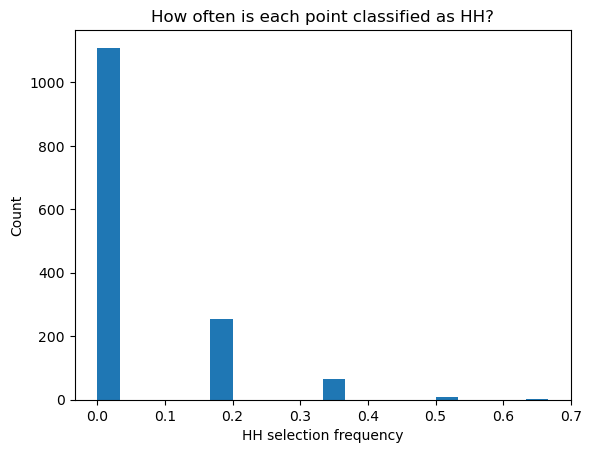

In [10]:
plt.hist(freq, bins=20)
plt.xlabel("HH selection frequency")
plt.ylabel("Count")
plt.title("How often is each point classified as HH?")
plt.show()

In [11]:
print("Fraction of points HH in >50% of runs:", (freq > 0.5).mean())

Fraction of points HH in >50% of runs: 0.002079002079002079


## 5. Run-to-run overlap (Jaccard)

In [12]:
J = hh_jaccard_matrix(hh_masks)

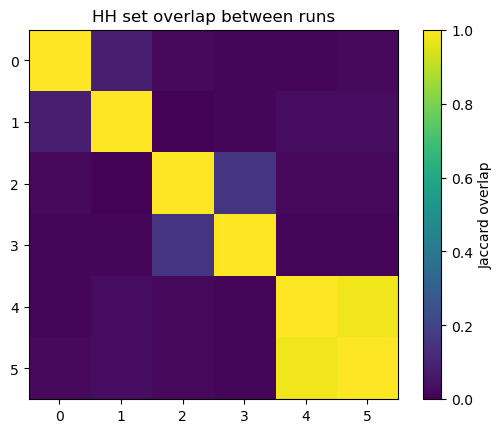

In [13]:
plt.imshow(J, vmin=0, vmax=1)
plt.colorbar(label="Jaccard overlap")
plt.title("HH set overlap between runs")
plt.show()

In [14]:
summarize_hh_stability(hh_masks)

{'mean_hh_fraction': 0.04954954954954955,
 'mean_jaccard': 0.09696934866175418,
 'min_jaccard': 0.011494252873563218,
 'max_jaccard': 0.9782608695652174}

## 6. Component-level stability (example run)

In [15]:
# Inspect components from the first run
run_dir = RUN_DIRS[0]
# Handle nested directory structure
if (run_dir / "P_test.npy").exists():
    data_dir = run_dir
else:
    seed_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and "seed=" in d.name and "eps=" in d.name])
    if seed_dirs:
        data_dir = seed_dirs[0]
    else:
        raise FileNotFoundError(f"Could not find P_test.npy in {run_dir} or its subdirectories")

P = np.load(data_dir / "P_test.npy")
metrics = np.load(data_dir / "metrics.npz")
X_test = pd.read_csv(data_dir / "X_test.csv")

v = metrics["variance"]
X_knn = X_test.select_dtypes(include=[np.number])
W = build_knn_graph(X_knn, k=10)

lisa = lisa_local(v, W)
_, components = extract_hh_components(lisa, W)

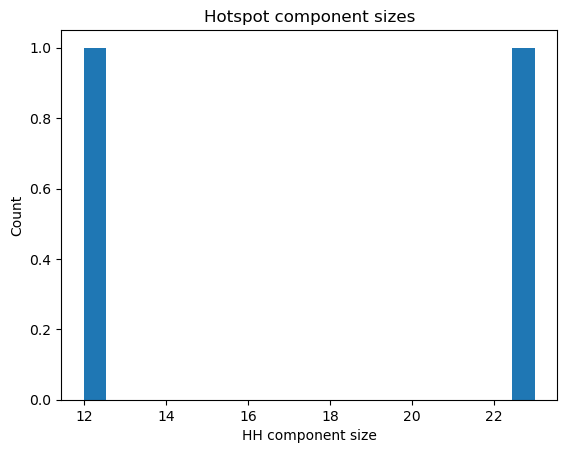

In [16]:
sizes = [len(v) for v in components.values()]
plt.hist(sizes, bins=20)
plt.xlabel("HH component size")
plt.ylabel("Count")
plt.title("Hotspot component sizes")
plt.show()

## 7. Takeaways

* Many points are consistently identified as HH across runs
* HH sets show substantial overlap (high Jaccard)
* Hotspot regions persist beyond a single random seed

➡️ Next: **Describe hotspot regions with simple, interpretable rules**